# RLHF 训练范式 vs ReAct 推理架构：异同与关联

本节通过对比 **RLHF**（Reinforcement Learning from Human Feedback，训练阶段的对齐方法）和 **ReAct**（Reasoning + Acting，推理阶段的 Agent 架构），帮助你厘清两者在概念上的相似性与本质差异。

> **为什么要对比这两者？**  
> 初学者常常在两个完全不同层次上看到「强化学习」和「Agent 行动」的字眼，容易混淆。RLHF 发生在**训练阶段**（改变模型权重），ReAct 发生在**推理阶段**（模型权重不变，只是推理模式不同）。认清这一本质区别，是理解现代 LLM 系统的基础。

## 1. RLHF 简介：训练阶段的强化学习对齐

### 1.1 核心目标

预训练的 LLM 学习的是「预测下一个 token」，不直接优化「有用、无害、诚实」等人类偏好目标。RLHF 的目标是**用人类偏好数据作为奖励信号，通过强化学习微调模型权重**，使模型行为与人类期望对齐。

### 1.2 标准三步流程

```
Step 1：人工标注偏好数据
  同一问题给出多个候选回答 → 人类标注员选择更好的

Step 2：训练奖励模型（Reward Model, RM）
  用偏好数据训练 RM，使其能对任意回答打分
  RM 充当「自动化的人类判断」

Step 3：用 RL 算法微调 LLM
  LLM（policy）生成回答 → RM 打分 → 梯度更新 LLM 权重
  常用算法：PPO、GRPO、DPO
```

### 1.3 RLHF 中的 RL 要素映射

| RL 概念 | RLHF 中的对应物 |
|---------|----------------|
| Agent | LLM（被训练的语言模型） |
| Environment | 奖励模型 + KL 惩罚项 |
| State | 当前对话上下文（prompt + 已生成的 token） |
| Action | 生成下一个 token |
| Reward | 奖励模型对完整回答的评分 |
| Policy | LLM 的参数（θ） |

> **关键点**：RLHF 训练**结束后**，模型权重被永久改变。推理时不再有奖励信号，也不再有 RL 循环——那些机制只在训练中存在。

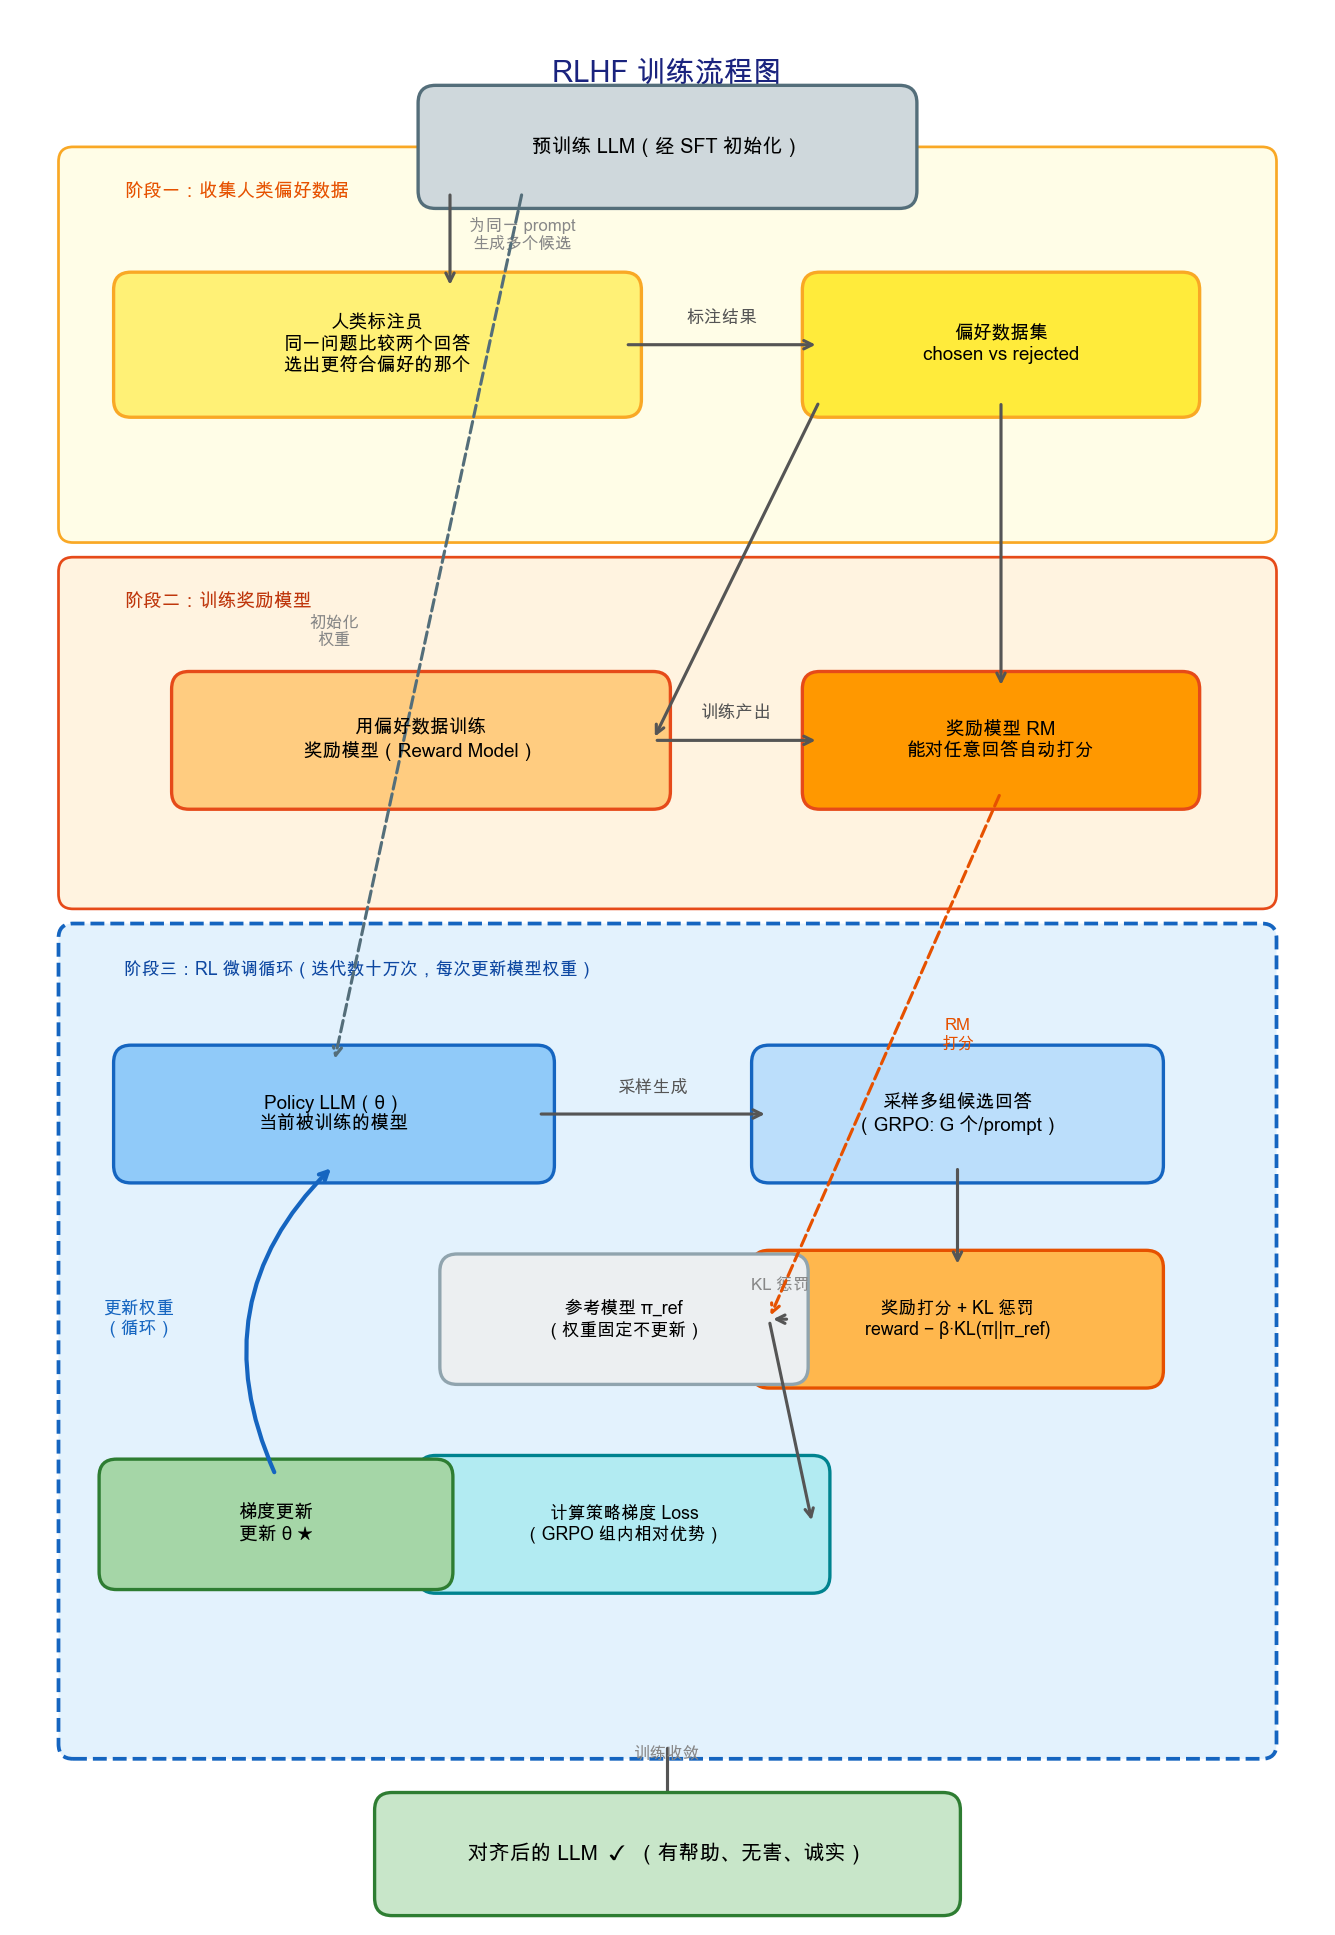

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

# ── 辅助函数 ────────────────────────────────────────────────
def rounded_box(ax, cx, cy, w, h, text, fc, ec='#444', fs=9.5, bold=False, zorder=3):
    """绘制圆角矩形并居中写入文字"""
    patch = FancyBboxPatch(
        (cx - w / 2, cy - h / 2), w, h,
        boxstyle="round,pad=0.12",
        facecolor=fc, edgecolor=ec, linewidth=1.6, zorder=zorder
    )
    ax.add_patch(patch)
    ax.text(cx, cy, text, ha='center', va='center',
            fontsize=fs, fontweight='bold' if bold else 'normal',
            multialignment='center', zorder=zorder + 1)

def vline(ax, cx, y_top, y_bot, color='#555', lw=1.5):
    """绘制带箭头的竖线（向下）"""
    ax.annotate('', xy=(cx, y_bot), xytext=(cx, y_top),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))

def hline(ax, x_left, x_right, cy, color='#555', lw=1.5, label=''):
    """绘制带箭头的横线（向右）"""
    ax.annotate('', xy=(x_right, cy), xytext=(x_left, cy),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    if label:
        ax.text((x_left + x_right) / 2, cy + 0.12, label,
                ha='center', va='bottom', fontsize=8.5, color='#555')

# ── 画布 ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 13), dpi=150)
ax.set_xlim(0, 9)
ax.set_ylim(0, 13)
ax.axis('off')
fig.patch.set_facecolor('white')

# ── 标题 ─────────────────────────────────────────────────────
ax.text(4.5, 12.6, 'RLHF 训练流程图', ha='center', va='center',
        fontsize=14, fontweight='bold', color='#1a237e')

# ══ 阶段一背景 ═══════════════════════════════════════════════
p1 = FancyBboxPatch((0.4, 9.5), 8.2, 2.5,
    boxstyle="round,pad=0.1", facecolor='#FFFDE7',
    edgecolor='#F9A825', linewidth=1.3, zorder=1)
ax.add_patch(p1)
ax.text(0.75, 11.85, '阶段一：收集人类偏好数据', fontsize=9, color='#E65100',
        fontweight='bold', va='top', zorder=2)

# ══ 阶段二背景 ═══════════════════════════════════════════════
p2 = FancyBboxPatch((0.4, 7.0), 8.2, 2.2,
    boxstyle="round,pad=0.1", facecolor='#FFF3E0',
    edgecolor='#E64A19', linewidth=1.3, zorder=1)
ax.add_patch(p2)
ax.text(0.75, 9.05, '阶段二：训练奖励模型', fontsize=9, color='#BF360C',
        fontweight='bold', va='top', zorder=2)

# ══ 阶段三背景（虚线框，强调"循环"）════════════════════════════
p3 = FancyBboxPatch((0.4, 1.2), 8.2, 5.5,
    boxstyle="round,pad=0.1", facecolor='#E3F2FD',
    edgecolor='#1565C0', linewidth=1.8, linestyle='--', zorder=1)
ax.add_patch(p3)
ax.text(0.75, 6.55, '阶段三：RL 微调循环（迭代数十万次，每次更新模型权重）',
        fontsize=8.5, color='#0D47A1', fontweight='bold', va='top', zorder=2)

# ── 起点：预训练 LLM ─────────────────────────────────────────
rounded_box(ax, 4.5, 12.1, 3.2, 0.6, '预训练 LLM（经 SFT 初始化）',
            '#CFD8DC', ec='#546E7A', bold=True)

# ── 阶段一节点 ───────────────────────────────────────────────
rounded_box(ax, 2.5, 10.75, 3.4, 0.75,
            '人类标注员\n同一问题比较两个回答\n选出更符合偏好的那个',
            '#FFF176', ec='#F9A825', fs=9)
rounded_box(ax, 6.8, 10.75, 2.5, 0.75,
            '偏好数据集\nchosen vs rejected',
            '#FFEB3B', ec='#F9A825', fs=9, bold=True)

# 阶段一内部箭头
hline(ax, 4.2, 5.55, 10.75, label='标注结果')

# 预训练LLM → 阶段一
vline(ax, 3.0, 11.8, 11.13)
ax.text(3.5, 11.5, '为同一 prompt\n生成多个候选', fontsize=8, color='#888',
        ha='center', va='center')

# ── 阶段二节点 ───────────────────────────────────────────────
rounded_box(ax, 2.8, 8.05, 3.2, 0.7,
            '用偏好数据训练\n奖励模型（Reward Model）',
            '#FFCC80', ec='#E64A19', fs=9)
rounded_box(ax, 6.8, 8.05, 2.5, 0.7,
            '奖励模型 RM\n能对任意回答自动打分',
            '#FF9800', ec='#E64A19', fs=9, bold=True)

# 阶段一 → 阶段二
vline(ax, 6.8, 10.37, 8.4)
ax.annotate('', xy=(4.4, 8.05), xytext=(5.55, 10.37),
            arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))

# 阶段二内部箭头
hline(ax, 4.4, 5.55, 8.05, label='训练产出')

# ── 阶段三节点 ───────────────────────────────────────────────
rounded_box(ax, 2.2, 5.5, 2.8, 0.7,
            'Policy LLM（θ）\n当前被训练的模型',
            '#90CAF9', ec='#1565C0', fs=9, bold=True)
rounded_box(ax, 6.5, 5.5, 2.6, 0.7,
            '采样多组候选回答\n（GRPO: G 个/prompt）',
            '#BBDEFB', ec='#1565C0', fs=9)
rounded_box(ax, 6.5, 4.1, 2.6, 0.7,
            '奖励打分 + KL 惩罚\nreward − β·KL(π||π_ref)',
            '#FFB74D', ec='#E65100', fs=8.5)
rounded_box(ax, 4.2, 2.7, 2.6, 0.7,
            '计算策略梯度 Loss\n（GRPO 组内相对优势）',
            '#B2EBF2', ec='#00838F', fs=8.5)
rounded_box(ax, 1.8, 2.7, 2.2, 0.65,
            '梯度更新\n更新 θ ★',
            '#A5D6A7', ec='#2E7D32', fs=9, bold=True)

# 参考模型（权重固定，提供 KL 约束）
rounded_box(ax, 4.2, 4.1, 2.3, 0.65,
            '参考模型 π_ref\n（权重固定不更新）',
            '#ECEFF1', ec='#90A4AE', fs=8.5)

# 阶段三内部箭头
# Policy LLM → 采样回答
hline(ax, 3.6, 5.2, 5.5, label='采样生成')
# 采样回答 → 奖励打分
vline(ax, 6.5, 5.15, 4.45)
# 参考模型 → 奖励打分（提供 KL）
hline(ax, 5.35, 5.2, 4.1)
ax.text(5.28, 4.3, 'KL 惩罚', fontsize=8, color='#888', ha='center')
# 奖励打分 → 计算 Loss
ax.annotate('', xy=(5.5, 2.7), xytext=(5.2, 4.1),
            arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))
# 计算 Loss → 梯度更新
hline(ax, 2.9, 2.9, 2.7)
# 梯度更新 → Policy LLM（向上循环，左侧弯折）
ax.annotate('', xy=(2.2, 5.15), xytext=(1.8, 3.03),
            arrowprops=dict(arrowstyle='->', color='#1565C0', lw=2.0,
                            connectionstyle='arc3,rad=-0.35'))
ax.text(0.85, 4.1, '更新权重\n（循环）', fontsize=8.5, color='#1565C0',
        ha='center', va='center', style='italic')

# 阶段二 RM → 阶段三打分
ax.annotate('', xy=(5.2, 4.1), xytext=(6.8, 7.7),
            arrowprops=dict(arrowstyle='->', color='#E65100', lw=1.5, linestyle='dashed'))
ax.text(6.5, 5.95, 'RM\n打分', fontsize=8, color='#E65100', ha='center')

# 预训练LLM → Policy LLM（初始化）
ax.annotate('', xy=(2.2, 5.85), xytext=(3.5, 11.8),
            arrowprops=dict(arrowstyle='->', color='#546E7A', lw=1.5, linestyle='dashed'))
ax.text(2.2, 8.7, '初始化\n权重', fontsize=8, color='#888', ha='center', style='italic')

# ── 收敛后输出 ───────────────────────────────────────────────
vline(ax, 4.5, 1.2, 0.75)
rounded_box(ax, 4.5, 0.45, 3.8, 0.6,
            '对齐后的 LLM  ✓  （有帮助、无害、诚实）',
            '#C8E6C9', ec='#2E7D32', fs=10, bold=True)
ax.text(4.5, 1.1, '训练收敛', fontsize=8, color='#888', ha='center')

plt.tight_layout()
plt.show()

## 2. ReAct 简介：推理阶段的 Agent 架构

### 2.1 论文背景

ReAct 来自 2022 年的论文 *ReAct: Synergizing Reasoning and Acting in Language Models*（Yao et al., 2022）。它是一种**推理时的 prompting 与架构模式**，不涉及任何训练或权重更新。

### 2.2 核心思想

ReAct 让模型交替产生两类输出：
- **Thought（思考）**：模型用自然语言推理当前情况，决定下一步该做什么
- **Action（行动）**：模型调用外部工具（搜索、计算器、API 等）

每次 Action 后，外部环境返回 **Observation（观测）**，模型据此继续 Thought → Action 循环，直到得出最终答案。

### 2.3 ReAct 交互格式示例

```
问题：法国的首都是哪里？它的人口大约是多少？

Thought 1: 我需要先找到法国首都，然后查询其人口。
Action 1: search("法国首都")
Observation 1: 法国首都是巴黎。

Thought 2: 已知首都是巴黎，现在查询巴黎人口。
Action 2: search("巴黎人口")
Observation 2: 巴黎市区人口约 220 万，大巴黎都市区约 1200 万。

Thought 3: 信息已足够，可以作答。
Final Answer: 法国首都是巴黎，市区人口约 220 万，大巴黎都市区约 1200 万。
```

### 2.4 ReAct 中的 RL 要素映射

| RL 概念 | ReAct 中的对应物 |
|---------|----------------|
| Agent | 执行推理的 LLM（推理时） |
| Environment | 外部工具 + 知识库（返回 Observation） |
| State | 当前对话历史（含所有 Thought/Action/Observation） |
| Action | 模型决定调用的工具及参数 |
| Reward | **无！** ReAct 没有显式奖励，任务完成即终止 |
| Policy | **固定！** 模型权重在推理中不更新 |

> **关键点**：ReAct 的「Agent 循环」只是一种**推理时的控制流**，没有梯度计算，没有权重更新，不是真正的 RL 训练过程。

/var/folders/k0/nlqc7vt13wd24wjjxks8w4f40000gn/T/ipykernel_50499/1058342730.py:133: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()


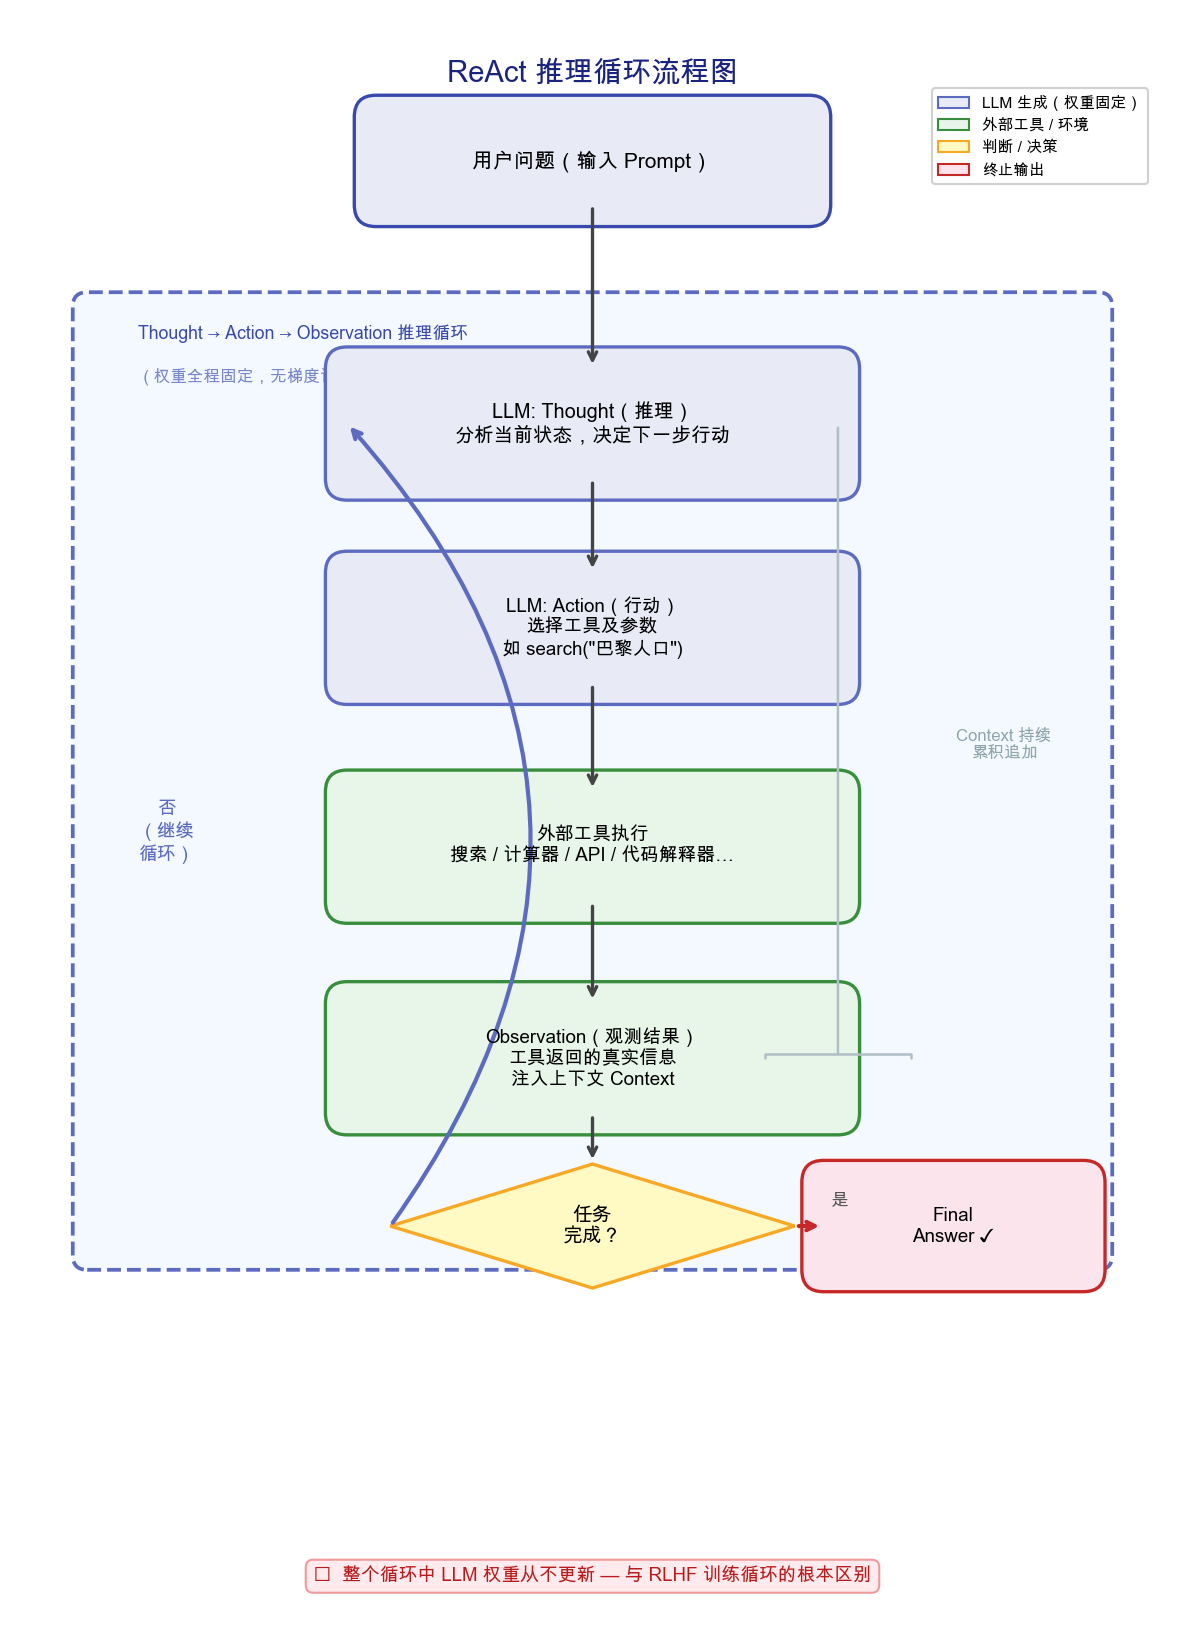

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.patches import Polygon

# ── 辅助函数（与上图复用相同风格）────────────────────────────
def rbox(ax, cx, cy, w, h, text, fc, ec='#444', fs=10, bold=False, zorder=3):
    patch = FancyBboxPatch(
        (cx - w/2, cy - h/2), w, h,
        boxstyle="round,pad=0.15",
        facecolor=fc, edgecolor=ec, linewidth=1.6, zorder=zorder
    )
    ax.add_patch(patch)
    ax.text(cx, cy, text, ha='center', va='center',
            fontsize=fs, fontweight='bold' if bold else 'normal',
            multialignment='center', zorder=zorder + 1)

def diamond(ax, cx, cy, w, h, text, fc, ec='#444', fs=9, zorder=3):
    """绘制菱形（用于判断节点）"""
    pts = [[cx, cy + h/2], [cx + w/2, cy],
           [cx, cy - h/2], [cx - w/2, cy]]
    poly = Polygon(pts, closed=True, facecolor=fc, edgecolor=ec, linewidth=1.6, zorder=zorder)
    ax.add_patch(poly)
    ax.text(cx, cy, text, ha='center', va='center',
            fontsize=fs, fontweight='bold', multialignment='center', zorder=zorder + 1)

def arr(ax, x1, y1, x2, y2, color='#444', lw=1.6, rad=0.0, label='', label_dx=0.15, label_dy=0.12):
    style = f'arc3,rad={rad}' if rad != 0 else 'arc3,rad=0'
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                connectionstyle=style))
    if label:
        mx = (x1 + x2) / 2 + label_dx
        my = (y1 + y2) / 2 + label_dy
        ax.text(mx, my, label, fontsize=8.5, color='#555',
                ha='left', va='bottom')

# ── 画布 ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 11), dpi=150)
ax.set_xlim(0, 8)
ax.set_ylim(0, 11)
ax.axis('off')
fig.patch.set_facecolor('white')

# ── 标题 ─────────────────────────────────────────────────────
ax.text(4.0, 10.6, 'ReAct 推理循环流程图', ha='center', va='center',
        fontsize=14, fontweight='bold', color='#1a237e')

# ── 循环区背景（蓝色虚线框） ──────────────────────────────────
loop_bg = FancyBboxPatch((0.5, 2.5), 7.0, 6.5,
    boxstyle="round,pad=0.1", facecolor='#F3F9FF',
    edgecolor='#5C6BC0', linewidth=1.8, linestyle='--', zorder=1)
ax.add_patch(loop_bg)
ax.text(0.85, 8.88, 'Thought → Action → Observation 推理循环', fontsize=8.5,
        color='#3949AB', fontweight='bold', va='top', zorder=2)
ax.text(0.85, 8.58, '（权重全程固定，无梯度计算，无权重更新）', fontsize=8,
        color='#7986CB', va='top', zorder=2)

# ── 图例说明（bbox_to_anchor 用数据坐标，需指定 bbox_transform）──
legend_items = [
    mpatches.Patch(facecolor='#E8EAF6', edgecolor='#5C6BC0', label='LLM 生成（权重固定）'),
    mpatches.Patch(facecolor='#E8F5E9', edgecolor='#388E3C', label='外部工具 / 环境'),
    mpatches.Patch(facecolor='#FFF9C4', edgecolor='#F9A825', label='判断 / 决策'),
    mpatches.Patch(facecolor='#FCE4EC', edgecolor='#C62828', label='终止输出'),
]
ax.legend(handles=legend_items, loc='upper right', fontsize=7.5,
          framealpha=0.9, edgecolor='#ccc',
          bbox_to_anchor=(7.9, 10.55), bbox_transform=ax.transData)

# ── 节点布局（从上到下） ──────────────────────────────────────

# 起点：用户问题
rbox(ax, 4.0, 10.0, 3.0, 0.6, '用户问题（输入 Prompt）',
     '#E8EAF6', ec='#3949AB', fs=10, bold=True)

# Thought
rbox(ax, 4.0, 8.2, 3.4, 0.75,
     'LLM: Thought（推理）\n分析当前状态，决定下一步行动',
     '#E8EAF6', ec='#5C6BC0', fs=9.5)

# Action
rbox(ax, 4.0, 6.8, 3.4, 0.75,
     'LLM: Action（行动）\n选择工具及参数\n如 search("巴黎人口")',
     '#E8EAF6', ec='#5C6BC0', fs=9)

# 外部工具
rbox(ax, 4.0, 5.3, 3.4, 0.75,
     '外部工具执行\n搜索 / 计算器 / API / 代码解释器…',
     '#E8F5E9', ec='#388E3C', fs=9)

# Observation
rbox(ax, 4.0, 3.85, 3.4, 0.75,
     'Observation（观测结果）\n工具返回的真实信息\n注入上下文 Context',
     '#E8F5E9', ec='#388E3C', fs=9)

# 判断：任务完成？
diamond(ax, 4.0, 2.7, 2.8, 0.85, '任务\n完成？',
        '#FFF9C4', ec='#F9A825', fs=9.5)

# 输出
rbox(ax, 6.5, 2.7, 1.8, 0.6, 'Final\nAnswer ✓',
     '#FCE4EC', ec='#C62828', fs=9, bold=True)

# ── 主流程箭头 ───────────────────────────────────────────────
arr(ax, 4.0, 9.7,  4.0, 8.58)                              # 问题 → Thought
arr(ax, 4.0, 7.82, 4.0, 7.18)                              # Thought → Action
arr(ax, 4.0, 6.42, 4.0, 5.68)                              # Action → 工具
arr(ax, 4.0, 4.92, 4.0, 4.23)                              # 工具 → Observation
arr(ax, 4.0, 3.47, 4.0, 3.13)                              # Observation → 判断

# 判断 → Final Answer（向右）
arr(ax, 5.4, 2.7, 5.6, 2.7, color='#C62828', lw=2.0, label='是')

# 判断 → Thought（否，左侧回环）
ax.annotate('', xy=(2.3, 8.2), xytext=(2.6, 2.7),
            arrowprops=dict(arrowstyle='->', color='#5C6BC0', lw=2.0,
                            connectionstyle='arc3,rad=0.4'))
ax.text(1.05, 5.4, '否\n（继续\n循环）', fontsize=9, color='#5C6BC0',
        ha='center', va='center', fontweight='bold')

# ── 侧注：Context 累积 ────────────────────────────────────────
ax.annotate('',
    xy=(5.7, 3.85), xytext=(5.7, 8.2),
    arrowprops=dict(arrowstyle='-[,widthB=3.5', color='#B0BEC5', lw=1.2))
ax.text(6.85, 6.0, 'Context 持续\n累积追加', fontsize=8, color='#90A4AE',
        ha='center', va='center', style='italic')

# ── 底部提示 ─────────────────────────────────────────────────
ax.text(4.0, 0.3, '⚠  整个循环中 LLM 权重从不更新 — 与 RLHF 训练循环的根本区别',
        ha='center', va='center', fontsize=9, color='#B71C1C',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFEBEE', edgecolor='#EF9A9A'))

plt.tight_layout()
plt.show()

## 3. 核心对比：RLHF vs ReAct

### 3.1 本质差异一览

| 维度 | RLHF | ReAct |
|------|------|-------|
| **发生阶段** | 训练阶段（Training-time） | 推理阶段（Inference-time） |
| **目标** | 改变模型权重，使行为对齐人类偏好 | 通过结构化推理解决复杂多步骤任务 |
| **是否更新权重** | ✅ 是，核心目的就是更新权重 | ❌ 否，权重完全固定 |
| **Reward 信号** | ✅ 必须有（奖励模型或可验证函数） | ❌ 无，靠任务完成判断成败 |
| **反馈来源** | 奖励模型 / 人类标注 / 规则函数 | 外部工具的执行结果（Observation） |
| **循环次数** | 数千~数百万次迭代（梯度更新） | 通常 3~20 轮 Thought-Action 循环 |
| **「记忆」持久性** | 永久（权重编码） | 临时（仅存在于当前上下文窗口） |
| **使用者** | 模型训练工程师 | 应用层开发者 / 用户 |
| **代表技术** | PPO、GRPO、DPO | LangChain Agent、AutoGPT、Function Calling |

### 3.2 一句话区分

- **RLHF**：「通过反复练习改变一个人的思维方式」（改变内在能力）
- **ReAct**：「在解决一道题时，边思考边查阅参考书」（利用已有能力 + 外部工具）

## 4. 相似性与关联：为何容易混淆

### 4.1 表面相似性

两者在**概念描述层**使用了相同的 RL 术语，这是混淆的主要来源：

| 共同术语 | RLHF 中的含义 | ReAct 中的含义 |
|----------|--------------|----------------|
| Agent | 被训练的模型 | 执行推理的模型实例 |
| Action | 生成 token | 调用工具 / 产生结构化输出 |
| Environment | 奖励模型 | 外部工具集合 |
| Observation | 奖励值 | 工具返回的结果 |
| Loop | 梯度更新迭代 | Thought-Action-Observation 循环 |

### 4.2 深层关联：相互增强

RLHF 和 ReAct 不只是名字相似——它们在实践中**深度互补**：

**① RLHF 提升 ReAct 效果**

经过 RLHF 对齐的模型（如 GPT-4、Claude）比未对齐的基础模型更擅长遵循 ReAct 格式约束：
- 更好地理解「只输出工具调用，不要多余内容」
- 更准确地在需要时停止，而不是「自我编造」工具结果
- 更强的指令跟随能力使 Thought 推理更清晰

**② 工具使用能力可通过 RLHF 强化**

可以设计奖励函数直接奖励「正确使用工具、然后得出正确答案」的行为：

```python
# 伪代码：针对工具使用的奖励函数
def tool_use_reward(trajectory):
    if used_correct_tool(trajectory) and final_answer_correct(trajectory):
        return 1.0   # 工具选对了，答案也对
    elif final_answer_correct(trajectory):
        return 0.5   # 没用工具但答对了（可能是靠记忆）
    else:
        return 0.0   # 答错了
```

这样训练出的模型天生更适合 ReAct 架构。

**③ Chain-of-Thought 是两者的交汇点**

ReAct 的 Thought 步骤 ≈ Chain-of-Thought（CoT）推理。RLHF 可以强化 CoT 风格的推理（如 DeepSeek R1 的 `<think>` 模块），训练出的模型自然就会在 ReAct 的 Thought 步骤中展现更深的推理链。

**④ 从 ReAct 到 RL 训练的闭环**

ReAct 的轨迹数据（Thought + Action + Observation 序列）可以被收集起来，用于：
- 监督微调（SFT）：让模型学习成功的工具使用模式
- RLHF 训练数据：对轨迹的质量进行人工评分，反哺 RL 训练

这形成了「推理时 ReAct 采样 → 训练时 RLHF 强化」的迭代飞轮。

## 5. 代码演示

### 5.1 用 Python 模拟 ReAct 推理循环

下面的代码模拟 ReAct 的核心控制流，帮助你理解其与 RLHF 训练循环的结构差异。

In [17]:
# 模拟 ReAct 推理循环
# 注意：这里没有任何梯度计算或权重更新，只是推理时的控制流

from dataclasses import dataclass
from typing import Optional


@dataclass
class Step:
    """ReAct 的单步记录：Thought / Action / Observation"""
    step_type: str   # "thought", "action", "observation", "answer"
    content: str


# ===========================================================
# 模拟「工具」：搜索引擎 + 计算器
# 在真实 ReAct 系统中，这些工具会调用真实 API
# ===========================================================

MOCK_SEARCH_DB = {
    "法国首都": "法国的首都是巴黎（Paris）。",
    "巴黎人口": "截至 2023 年，巴黎市区人口约 220 万，大巴黎都市圈约 1200 万。",
    "埃菲尔铁塔高度": "埃菲尔铁塔高约 330 米（含天线），建于 1889 年。",
}


def tool_search(query: str) -> str:
    """模拟搜索工具：返回预设结果"""
    for key, value in MOCK_SEARCH_DB.items():
        if key in query:
            return value
    return f"未找到关于 '{query}' 的信息。"


def tool_calculator(expression: str) -> str:
    """模拟计算器工具：安全计算数学表达式"""
    try:
        # 只允许数字和基本运算符，防止代码注入
        allowed = set("0123456789.+-*/() ")
        if not all(c in allowed for c in expression):
            return "错误：表达式包含非法字符"
        result = eval(expression)
        return f"计算结果：{result}"
    except Exception as e:
        return f"计算失败：{e}"


TOOLS = {
    "search": tool_search,
    "calculator": tool_calculator,
}


# ===========================================================
# 模拟「LLM」：硬编码的决策逻辑
# 真实场景中这里是对 LLM API 的调用
# ===========================================================

def mock_llm_step(question: str, history: list[Step]) -> Step:
    """
    模拟 LLM 的一步推理输出。
    真实系统中，这里会把 question + history 拼成 prompt 发给 LLM，
    LLM 返回下一步的 Thought 或 Action 或 Final Answer。
    """
    # 用 thought + action 的总数确定当前阶段
    # Observation 由工具自动产生，不计入 LLM 的决策轮次
    stage = len([s for s in history if s.step_type in ("thought", "action")])

    # 根据阶段决定下一步（模拟预设的推理路径）
    if stage == 0:
        return Step("thought", "我需要先查找法国的首都是哪个城市。")
    elif stage == 1:
        return Step("action", 'search("法国首都")')
    elif stage == 2:
        return Step("thought", "已知首都是巴黎，接下来查询巴黎的人口数量。")
    elif stage == 3:
        return Step("action", 'search("巴黎人口")')
    elif stage == 4:
        return Step("thought", "已有足够信息，可以给出完整答案。")
    else:
        return Step("answer", "法国的首都是巴黎，市区人口约 220 万，大巴黎都市圈约 1200 万。")


def parse_action(action_str: str) -> tuple[str, str]:
    """从 action 字符串中解析工具名和参数，如 'search("巴黎人口")'"""
    tool_name = action_str.split("(")[0].strip()
    arg = action_str.split("(")[1].rstrip(")").strip('"\' ')
    return tool_name, arg


# ===========================================================
# ReAct 主循环
# ===========================================================

def react_loop(question: str, max_steps: int = 10) -> str:
    """
    ReAct 推理主循环。
    
    核心流程：
      LLM Thought → LLM Action → Tool Observation → LLM Thought → ...
    
    与 RLHF 训练循环的本质区别：
      - 没有 loss 计算
      - 没有梯度反向传播
      - 没有权重更新
      - LLM 参数在整个过程中完全固定
    """
    history: list[Step] = []
    print(f"❓ 问题：{question}")
    print("=" * 60)

    for i in range(max_steps):
        # Step A：LLM 产生下一步（Thought 或 Action 或 Final Answer）
        next_step = mock_llm_step(question, history)
        history.append(next_step)

        if next_step.step_type == "thought":
            thought_num = len([s for s in history if s.step_type == "thought"])
            print(f"💭 Thought {thought_num}: {next_step.content}")

        elif next_step.step_type == "action":
            print(f"🔧 Action:  {next_step.content}")
            # Step B：执行工具，得到 Observation
            tool_name, arg = parse_action(next_step.content)
            if tool_name in TOOLS:
                obs_content = TOOLS[tool_name](arg)
            else:
                obs_content = f"未知工具：{tool_name}"
            obs_step = Step("observation", obs_content)
            history.append(obs_step)
            print(f"👁  Observation: {obs_content}")

        elif next_step.step_type == "answer":
            print(f"✅ Final Answer: {next_step.content}")
            return next_step.content

        print()

    return "达到最大步数，未能得出答案。"


# 运行 ReAct 演示
result = react_loop("法国的首都是哪里？它的人口大约是多少？")

❓ 问题：法国的首都是哪里？它的人口大约是多少？
💭 Thought 1: 我需要先查找法国的首都是哪个城市。

🔧 Action:  search("法国首都")
👁  Observation: 法国的首都是巴黎（Paris）。

💭 Thought 2: 已知首都是巴黎，接下来查询巴黎的人口数量。

🔧 Action:  search("巴黎人口")
👁  Observation: 截至 2023 年，巴黎市区人口约 220 万，大巴黎都市圈约 1200 万。

💭 Thought 3: 已有足够信息，可以给出完整答案。

✅ Final Answer: 法国的首都是巴黎，市区人口约 220 万，大巴黎都市圈约 1200 万。


In [10]:
# ===========================================================
# 对比：RLHF 训练循环的结构（伪代码，仅展示架构，不可运行）
# ===========================================================

def rlhf_training_loop_pseudocode():
    """
    RLHF 训练循环的伪代码框架，与 ReAct 推理循环形成对比。
    
    关键区别：
      - 每次迭代都会更新模型权重（optimizer.step）
      - 奖励信号驱动梯度计算
      - 需要数千~数百万次迭代
      - 结束后模型能力永久改变
    """
    # 初始化（一次性）
    policy_model = load_pretrained_llm()        # 待训练的语言模型
    reward_model = load_reward_model()          # 奖励模型（已训练好）
    reference_model = load_pretrained_llm()     # 参考模型（用于 KL 约束，权重固定）
    optimizer = AdamW(policy_model.parameters())

    for iteration in range(NUM_TRAINING_STEPS):  # 数千~数百万次迭代
        # Step 1：采样 prompt
        prompts = sample_from_dataset()

        # Step 2：policy 生成回答（前向传播）
        responses = policy_model.generate(prompts)

        # Step 3：奖励模型打分（关键：奖励驱动学习方向）
        rewards = reward_model.score(prompts, responses)

        # Step 4：计算 KL 散度惩罚（防止 policy 偏离参考模型太远）
        kl_penalty = compute_kl_divergence(policy_model, reference_model, prompts)
        adjusted_rewards = rewards - KL_COEFF * kl_penalty

        # Step 5：计算损失 + 反向传播（ReAct 中完全没有这步！）
        loss = compute_policy_gradient_loss(responses, adjusted_rewards)
        loss.backward()
        optimizer.step()         # 更新模型权重 ← 这是 RLHF 与 ReAct 最本质的区别
        optimizer.zero_grad()

    return policy_model   # 训练完成，返回对齐后的模型


print("RLHF 训练循环 vs ReAct 推理循环 — 结构对比")
print()
print("┌─────────────────────────────────────────────────────────┐")
print("│                     RLHF 训练循环                       │")
print("│  for step in range(数百万次):                            │")
print("│    response = policy_model.generate(prompt)              │")
print("│    reward   = reward_model.score(response)               │")
print("│    loss     = policy_gradient_loss(reward)               │")
print("│    loss.backward()    ← 计算梯度                         │")
print("│    optimizer.step()   ← 更新权重 ★                       │")
print("└─────────────────────────────────────────────────────────┘")
print()
print("┌─────────────────────────────────────────────────────────┐")
print("│                     ReAct 推理循环                      │")
print("│  while not done:                                         │")
print("│    thought = llm.generate(context)   ← 权重固定          │")
print("│    action  = llm.generate(context)   ← 权重固定          │")
print("│    obs     = tool.execute(action)    ← 外部工具          │")
print("│    context = context + thought + action + obs            │")
print("│    # 没有 loss，没有梯度，没有权重更新 ★                  │")
print("└─────────────────────────────────────────────────────────┘")

RLHF 训练循环 vs ReAct 推理循环 — 结构对比

┌─────────────────────────────────────────────────────────┐
│                     RLHF 训练循环                       │
│  for step in range(数百万次):                            │
│    response = policy_model.generate(prompt)              │
│    reward   = reward_model.score(response)               │
│    loss     = policy_gradient_loss(reward)               │
│    loss.backward()    ← 计算梯度                         │
│    optimizer.step()   ← 更新权重 ★                       │
└─────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────┐
│                     ReAct 推理循环                      │
│  while not done:                                         │
│    thought = llm.generate(context)   ← 权重固定          │
│    action  = llm.generate(context)   ← 权重固定          │
│    obs     = tool.execute(action)    ← 外部工具          │
│    context = context + thought + action + obs            │
│    # 没有 loss，没有梯度，没有权重更新 ★

## 6. 概念层次图：RLHF 与 ReAct 的位置

理解两者在 LLM 系统整体架构中的位置，有助于避免混淆：

```
╔══════════════════════════════════════════════════════════════╗
║              LLM 系统全栈（从底层到顶层）                     ║
╠══════════════════════════════════════════════════════════════╣
║  【应用层】  ReAct / Function Calling / Multi-Agent          ║
║             推理时 Agent 架构，模型权重固定，调用外部工具      ║
╠══════════════════════════════════════════════════════════════╣
║  【推理层】  Chain-of-Thought / Self-Consistency / ToT        ║
║             推理时 prompting 策略，不涉及权重                 ║
╠══════════════════════════════════════════════════════════════╣
║  【模型层】  经 RLHF 对齐的 LLM（ChatGPT、Claude、DeepSeek） ║
║             ← RLHF 在此层发挥作用（训练时修改权重）           ║
╠══════════════════════════════════════════════════════════════╣
║  【预训练层】 Base LLM（GPT-3、LLaMA、Qwen-base 等）          ║
║              预测下一个 token，未经对齐                       ║
╚══════════════════════════════════════════════════════════════╝
```

RLHF 负责把 Base LLM 打磨成对齐的对话模型（**向下构建能力**），ReAct 负责在对话模型上搭建智能 Agent 系统（**向上扩展能力**）。两者的工作层次完全不同，但彼此互补。

## 7. 进阶：训练时 RL + 推理时 ReAct 的融合趋势

### 7.1 工具增强型 RLHF

最新研究（如 Toolformer、ToolRL）将工具使用能力直接写入 RLHF 奖励函数：

```
训练时：
  prompt → LLM 生成 [Thought + Action] 轨迹
         → 执行工具 → 得到 Observation
         → LLM 继续生成最终答案
         → 奖励函数评估整个轨迹质量
         → 梯度更新（RLHF）

效果：训练完成后，模型「天生」会用工具，ReAct 推理更可靠
```

### 7.2 Online RLHF 与 ReAct 数据飞轮

```
①  部署 ReAct Agent → 收集真实用户交互轨迹
②  人工标注轨迹质量 → 得到偏好数据
③  用偏好数据做 RLHF → 模型 ReAct 能力提升
④  用更强模型重新部署 ReAct → 采集更高质量轨迹
⑤  循环回到 ①
```

这就是 GPT-4 Plugin、Gemini Function Calling 等产品持续改进的底层逻辑：**ReAct 产出数据，RLHF 消化数据，形成正向飞轮**。

### 7.3 DeepSeek R1 与 ReAct 的关系

本章 Section 01 介绍的 DeepSeek R1 使用 GRPO 强化了 `<think>` 推理模式。这种训练出的推理能力与 ReAct 高度兼容：

- R1 的 `<think>` 块 ≈ ReAct 的 Thought 步骤（更深层的推理）
- R1 经过 RLHF 增强后，在 ReAct 框架下使用工具时推理质量更高
- 未来的方向：直接用 RLHF 在 `<think>` + 工具调用 + 最终答案的完整轨迹上做端到端强化训练

## 8. 本节小结

### 核心结论

| | RLHF | ReAct |
|--|------|-------|
| **是什么** | 训练范式 | 推理架构 |
| **何时发生** | 模型训练时 | 模型推理时 |
| **改变什么** | 模型权重（永久） | 推理上下文（临时） |
| **RL 是否真实存在** | ✅ 真实的 RL 优化 | ❌ 借用 RL 概念的类比 |
| **互相关系** | 打好底层能力 | 利用底层能力 |

### 关键洞察

1. **层次不同，目标不同**：RLHF 在训练层改变模型能力，ReAct 在应用层编排模型能力
2. **术语重叠是混淆根源**：两者都借用 Agent/Action/Environment 的 RL 术语，但含义截然不同
3. **实践中相互增强**：RLHF 对齐的模型是更可靠的 ReAct Agent；ReAct 轨迹可以反哺 RLHF 训练数据
4. **融合是趋势**：工具增强型 RLHF 将两者统一到同一训练-推理闭环中

### 思考练习

1. 如果你在 ReAct 推理循环中发现模型总是选错工具，你应该优先考虑改进训练（RLHF）还是改进 prompt（ReAct）？为什么？
    Prompt
2. RLHF 训练完成后，「奖励信号」还存在吗？它去哪里了？
    在模型权重中。
3. ReAct 的 Observation 和 RLHF 的 Reward 都是「来自环境的反馈」，核心区别是什么？
    Observation 是模型在推理时的输入，Reward 是模型在训练时的反馈。
4. 如果你想让模型「学会」正确使用某个新工具，你会选择 RLHF 还是 ReAct 提示工程？哪种更持久？
    RLHF

---

**延伸阅读**
- [ReAct 原始论文](https://arxiv.org/abs/2210.03629)（Yao et al., 2022）
- [InstructGPT / RLHF 论文](https://arxiv.org/abs/2203.02155)（Ouyang et al., 2022）
- [Toolformer](https://arxiv.org/abs/2302.04761)：将工具使用能力通过自监督训练写入模型权重的早期探索